## Generative models for modality integration

In [1]:
import os
import sys
import gc

import tifffile
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from ml_collections import ConfigDict

from skimage import io
from skimage.transform import rescale
from skimage.exposure import rescale_intensity
from skimage.color import rgb2gray
# from denoising_diffusion_pytorch import Unet, GaussianDiffusion, Trainer

In [22]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({'font.size': 10})
rcParams.update({'figure.dpi': 300})
rcParams.update({'savefig.dpi': 300})

import warnings
warnings.filterwarnings('ignore')

### Load H&E images

In [ ]:
%ls ../data/he_imgs/res

In [ ]:
data_path = '../data/he_imgs/res/'
img_stacked = tifffile.imread(os.path.join(data_path, 'valis_stacked.ome.tif'))
img_stacked.shape

In [ ]:
# Trim artifacts

_, nimg, ylen, xlen = img_stacked.shape
side_len = 256*10
ymin, ymax = ylen//2-side_len//2, ylen//2+side_len//2
xmin, xmax = xlen//2-side_len//2, xlen//2+side_len//2

ncol = 4
nrow = nimg // ncol
if nimg % ncol != 0:
    nrow += 1

fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 3.2*nrow), dpi=200)
idx = 0
for r in range(nrow):
    for c in range(ncol):
        if idx < nimg:
            axes[r, c].imshow(img_stacked[:, idx, ymin:ymax, xmin:xmax].transpose(1,2,0))
        else:
            axes[r, c].axis('off')
        idx += 1
        
plt.tight_layout()
plt.show()
del idx, r, c

In [ ]:
# Generate training images
img_size = 256
scale=img_size/side_len

imgs = [rescale(img_stacked[:, i, ymin:ymax, xmin:xmax].transpose(1,2,0),
               scale=scale, preserve_range=True, channel_axis=-1).astype(np.uint8)
        for i in range(nimg)]

In [ ]:
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 3.2*nrow), dpi=200)
idx = 0
for r in range(nrow):
    for c in range(ncol):
        if idx < nimg:
            axes[r, c].imshow(imgs[idx])
        else:
            axes[r, c].axis('off')
        idx += 1
        
plt.tight_layout()
plt.suptitle('Low-res H&E slices', y=1.01)
plt.show()
del idx, r, c

In [ ]:
train_path = '../data/he_imgs/ddpm_train'
if not os.path.exists(train_path):
    os.makedirs(train_path, exist_ok=True)

for i, img in enumerate(imgs):
    id = '0'+str(i) if i < 10 else str(i)
    
    # Save as tif
    # filename = 'he_{}.tiff'.format(id)
    # tifffile.imwrite(os.path.join(train_path, filename), 
    #                  rescale_intensity(imgs_ds[i], out_range=(0, 1)))

    # Save as png
    filename = 'he_{}.png'.format(id)
    io.imsave(os.path.join(train_path, filename), img)

### Train standard DDPM model

In [ ]:
base_dim = 64
layer_mults = (1,2,3,4)
img_size = 256
timesteps = 500
sampling_timesteps = 250

batch_size = 2
lr = 1e-5
nepoch = 5000
ema_decay = 0.999

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = Unet(dim=base_dim, dim_mults=layer_mults).to(device)

diffusion = GaussianDiffusion(model,
                              image_size=img_size,
                              timesteps=timesteps,
                              sampling_timesteps=sampling_timesteps).to(device)

In [ ]:
trainer = Trainer(diffusion,
                  folder='../data/he_imgs/ddpm_train/',
                  train_batch_size=batch_size,
                  train_lr=lr,
                  train_num_steps=nepoch,
                  gradient_accumulate_every=16,
                  ema_decay=ema_decay,
                  amp=True,
                  calculate_fid=False)


In [ ]:
trainer.train()

In [ ]:
trainer.save(milestone=1000)

#### Interpolation btw adjacent slices:

- Input dimension converted to: `(B, C, Y, X)`
- Pixel intensities normalized to [0, 1] per channel

In [ ]:
# Load model
trainer.load(10)

In [ ]:
x0 = io.imread('../data/he_imgs/ddpm_train/he_04.png')
x1 = io.imread('../data/he_imgs/ddpm_train/he_05.png')

In [ ]:
def interp_z_slice(
    ddpm_model,
    x0_rgb,
    x1_rgb,
    device=None,
    t=None,
    alpha=0.5
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ddpm_model = ddpm_model.to(device)
    
    # Norm by channel, convert to (B, C, Y, X) tensors
    x0 = np.array([rescale_intensity(chan, out_range=(0, 1))
                   for chan in x0_rgb])
    x0 = torch.tensor(x0.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    x1 = np.array([rescale_intensity(chan, out_range=(0, 1))
                   for chan in x1_rgb])
    x1 = torch.tensor(x1.transpose(2, 0, 1)).unsqueeze(0).float().to(device)

    # Interpolate, convert back to (Y, X, C)
    x0_x1_interp = ddpm_model.interpolate(x0, x1, lam=alpha)
    x0_x1_interp = x0_x1_interp.detach().cpu().squeeze().numpy().transpose(1,2,0)

    # DEBUG: Weird bug flipping the img somehow...
    x0_x1_interp = np.flip(x0_x1_interp, axis=1)

    return np.round(x0_x1_interp*255).astype(np.uint8)
    

In [ ]:
x0 = io.imread('../data/he_imgs/ddpm_train/he_04.png')
x1 = io.imread('../data/he_imgs/ddpm_train/he_05.png')
x0_x1_interp = interp_z_slice(diffusion, x0, x1, device=device)

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))
ax1.imshow(rgb2gray(x0))
ax2.imshow(rgb2gray(x1))
ax3.imshow(rgb2gray(x0_x1_interp))
plt.tight_layout()
plt.show()

In [ ]:
# Interpolating w/ different alphas
interps = []
alphas = np.linspace(0, 1, 6)[1:-1]
for alpha in alphas:
    interp = interp_z_slice(diffusion, x0, x1, device=device)
    interp = rgb2gray(interp)
    interps.append(interp)

In [ ]:
fig, axes = plt.subplots(1, len(alphas), figsize=(2*len(alphas), 2.2))
for (ax, alpha, interp) in zip(axes, alphas, interps):
    ax.imshow(interp)
    ax.set_title(r'Interp ($\alpha={}$)'.format(np.round(alpha, 1)))
plt.tight_layout()
plt.show()

### Load CyIF images

- Create 3-channel zonation-informed input: `GS` (R) + `CYP3A4` (G) + `ASS` (B)
- Create low-dim noisy estimation on zonation dynamics $p(z)$ w/ determinsitic heat diffusion

In [ ]:
from skimage.exposure import equalize_adapthist, rescale_intensity
from skimage.transform import rescale
from skimage.filters import sobel, threshold_otsu, threshold_minimum
from skimage.filters import gaussian as gaussian_blur

sys.path.append('..')
import IO, zonation

In [ ]:
from importlib import reload
reload(IO)
reload(zonation)

In [ ]:
data_path = '../data/cycif/adj/'
zone_labels = ['GS 647', 'CYP3A4', 'ASS1 PE']

In [ ]:
cyif_annot_imgs = IO.load_annot_tiffs(data_path, ext='ome.tif')
filenames = list(cyif_annot_imgs.keys())
imgs = [np.array([img[label] for label in zone_labels])
        for _, img in cyif_annot_imgs.items()]

# Trim middle FOV
radius = 2048

imgs_trimmed = []
for img in imgs:
    ny, nx = img.shape[-2:]
    ylow = ny//2 - radius
    yhigh = ny//2 + radius
    imgs_trimmed.append(
        np.array([
            equalize_adapthist(chnl) 
            for chnl in img[:, ylow:yhigh, ylow:yhigh]
        ])
    )

del img, ny, nx, ylow, yhigh

In [ ]:
def disp_cyif_chans(imgs, title=None, ncols=4):
    """Display 3-channel zonation image"""
    depth = len(imgs)
    nrows = depth // ncols if depth % ncols == 0 else depth // ncols + 1
    
    idx = 0
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3.2*nrows), dpi=200)
    for r in range(nrows):
        for c in range(ncols):
            if idx >= depth:
                axes[r, c].axis('off')
                continue
            axes[r, c].imshow(imgs[idx].transpose(1,2,0))
            idx += 1
            
    plt.tight_layout()
    plt.suptitle(title, y=1.01)
    plt.show()
    return None

In [ ]:
disp_cyif_chans(imgs_trimmed, title='CyIFs (3-chan zonation markers)')

In [ ]:
# Rescale to high-res (512 x 512) images
out_path = '../data/cycif/zonation_hires/'
if not os.path.exists(out_path):
    os.makedirs(out_path, exist_ok=True)

in_dim = 4096
out_dim = 512
scale = out_dim / in_dim

for filename, img in zip(filenames, imgs_trimmed):
    filename = filename.split('.')[0] + '.tif'
    img_ds = rescale(img, scale=scale, preserve_range=True, channel_axis=0)
    tifffile.imwrite(os.path.join(out_path, filename), img_ds)

del filename, img, img_ds, out_path

# Rescale to low-res (128 x 128) images
out_path = '../data/cycif/zonation_lowres/'
if not os.path.exists(out_path):
    os.makedirs(out_path, exist_ok=True)

for filename, img in zip(filenames, imgs):
    img_lowres = rescale(img, scale=0.25, preserve_range=True, channel_axis=0)
    tifffile.imwrite(os.path.join(out_path, filename), img_lowres)

del filename, img, img_lowres, out_path

**Heat diffusion on low-dim images**

In [ ]:
# data_path = '../data/cycif/zonation_hires/'
# filenames = [f for f in sorted(os.listdir(data_path))
#              if f[-3:] == 'tif']

# imgs = [tifffile.imread(os.path.join(data_path, f))
#         for f in filenames]


# data_path = '../data/cycif/zonation_lowres/'
# filenames = [f for f in sorted(os.listdir(data_path))
#              if f[-3:] == 'tif']

# imgs = [tifffile.imread(os.path.join(data_path, f))
#         for f in filenames]

Generate 64 x 64 low-res heat diffusion: has to be run on hi-res image (o.w. GS signal loss...)


In [ ]:
def create_vein_prior(img, sigma=1.5):
    assert img.ndim == 3 and img.shape[0] == 3, "3-dim zonation marker images"
    cv_chan = gaussian_blur(img[0], sigma=sigma)
    cv_threshold = threshold_otsu(cv_chan)
    cv_mask = (cv_chan > cv_threshold).astype(np.uint8)

    pv_chan = gaussian_blur(img[-1], sigma=sigma)
    pv_threshold = threshold_otsu(pv_chan)
    pv_mask = (pv_chan > pv_threshold).astype(np.uint8)

    vein_prior = np.zeros_like(cv_chan, dtype=np.int8)
    vein_prior[np.logical_and(pv_mask == 1, cv_mask == 0)] = -1
    vein_prior[np.logical_and(pv_mask == 0, cv_mask == 1)] = 1

    return vein_prior
    

In [ ]:
vein_path = '../data/cycif/zonation_mask/'
# if not os.path.exists(vein_path):
#     os.makedirs(vein_path, exist_ok=True)

# vein_priors = []
# for filename, img in zip(filenames, imgs):
#     vein_prior = create_vein_prior(img)
#     vein_priors.append(vein_prior)

#     filename = 'CyIF_vein_prior_{}.tif'.format(filename.split('.')[0][-2:])
#     tifffile.imwrite(os.path.join(vein_path, filename), vein_prior)

# del filename, img, vein_prior

# Load from file
# ...

In [ ]:
temps = []
for vein_prior in vein_priors:
    model = zonation.HeatDiffusion(vein_prior=vein_prior, ndim=2)
    U_i, interior_nodes = model.get_interior_U()
    U = model.inference_zone_dynamics()
    temps.append(U)


In [ ]:
def disp_zone_temps(imgs, title=None, ncols=4):
    """Display 3-channel zonation image"""
    depth = len(imgs)
    nrows = depth // ncols if depth % ncols == 0 else depth // ncols + 1
    
    idx = 0
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3.2*nrows), dpi=200)
    for r in range(nrows):
        for c in range(ncols):
            if idx >= depth:
                axes[r, c].axis('off')
                continue
            axes[r, c].imshow(imgs[idx], cmap='coolwarm')
            idx += 1
            
    plt.tight_layout()
    plt.suptitle(title, y=1.01)
    plt.show()
    return None

In [ ]:
# Save downscaled (64 x 64) zonation priors as p(z)

vein_path = '../data/cycif/zonation_mask/'
if not os.path.exists(vein_path):
    os.makedirs(vein_path, exist_ok=True)

# in_dim = 512
# out_dim = 64
# scale= out_dim / in_dim
# pz_means = []

# for filename, temp in zip(filenames, temps):
#     pz_mean = rescale(temp, scale=scale, preserve_range=True)
#     pz_means.append(pz_mean)

#     filename = 'CyIF_dynamics_{}.tif'.format(filename.split('.')[0][-2:])
#     tifffile.imwrite(os.path.join(vein_path, filename), pz_mean)


# del filename, temp, pz_mean
# disp_zone_temps(pz_means, title=r'CyIF zonation priors $p(z)$')

# Load from file
# ...

### Vanilla $\beta$-VAE for Cy-IF reconstruction

- Benchmark performance w/ linear layers vs. Conv2d
- Uninformative priors $p(z)$ (trying full covariance other than diag.)

In [ ]:
from torch.utils.data import DataLoader

sys.path.append('..')
sys.path.append('../models/')

import utils, configs, constants
from dataset import CyIFDataset
import bvae, model_train, model_eval

In [ ]:
from importlib import reload

reload(utils)
reload(configs)
reload(bvae)
reload(model_train)
reload(model_eval)

#### Training b-VAE 1D

In [ ]:
model_configs = configs.set_model_configs(
    drop_rate = 0.2,
    beta = 0.33,
    pz_std = 1,
    c_base = 128,
    layer_mults = [8, 4],
    ydim = 128, 
    xdim = 128,
    latent_dim = 256,
    device = torch.device('cpu')
)

train_configs = configs.set_train_configs(
    # data_path = '../data/cycif/zonation_hires/',
    data_path = '../data/cycif/zonation_lowres/',
    lr = 1e-4,
    n_epochs = 300
)


In [ ]:
model = bvae.BetaVAE(model_configs)
dataloader = DataLoader(
    CyIFDataset(
        data_path = train_configs.data_path
    )
)

In [ ]:
model, loss_dict = model_train.train(model,
                                     dataloader,
                                     train_configs, 
                                     model_configs)

In [ ]:
loss_tot = torch.tensor(loss_dict['total']).cpu().numpy()
loss_nll = torch.tensor(loss_dict['NLL']).cpu().numpy()
loss_kl = torch.tensor(loss_dict['KL']).cpu().numpy()

In [ ]:
n_epochs = train_configs.n_epochs
beta = model_configs.beta

step = 10

plt.figure(figsize=(6, 4))
plt.plot(np.arange(n_epochs)[::step], loss_tot[::step], '.--',  label = 'Total loss')
plt.plot(np.arange(n_epochs)[::step], loss_nll[::step], '.--', color='orange', label = r'$\Vert x - \hat{x} \Vert^2$')
plt.plot(np.arange(n_epochs)[::step], loss_kl[::step], '.--', color='green', label = r'$D_{\text{KL}}(q(z \mid x) || p(z))$')

plt.title('Training logs')
plt.legend()
plt.show()

In [ ]:
torch.save(model.state_dict(), 'results/bvae_1d_lowres_std_norm.pt')

#### Training b-VAE 2D

In [ ]:
# Model configs
model_configs = configs.set_model_configs(
    drop_rate = 0.2,
    beta = 0.33,
    pz_std = 1,
    ydim = 128,
    xdim = 128,
    latent_dim = 256,
    device = torch.device('cpu')
)

train_configs = configs.set_train_configs(
    # data_path = '../data/cycif/zonation_hires/',
    data_path = '../data/cycif/zonation_lowres/',
    lr = 1e-3,
    n_epochs = 300
)


In [ ]:
model = bvae.BetaVAE2D(model_configs)
dataloader = DataLoader(
    CyIFDataset(
        data_path=train_configs.data_path
    )
)

In [ ]:
model, loss_dict = model_train.train(model,
                                     dataloader,
                                     train_configs, 
                                     model_configs)

In [ ]:
loss_tot = torch.tensor(loss_dict['total']).cpu().numpy()
loss_nll = torch.tensor(loss_dict['NLL']).cpu().numpy()
loss_kl = torch.tensor(loss_dict['KL']).cpu().numpy()

In [ ]:
n_epochs = train_configs.n_epochs
beta = model_configs.beta

step = 10

plt.figure(figsize=(6, 4))
plt.plot(np.arange(n_epochs)[::step], loss_tot[::step], '.--',  label = 'Total loss')
plt.plot(np.arange(n_epochs)[::step], loss_nll[::step], '.--', color='orange', label = r'$\Vert x - \hat{x} \Vert^2$')
plt.plot(np.arange(n_epochs)[::step], loss_kl[::step], '.--', color='green', label = r'$D_{\text{KL}}(q(z \mid x) || p(z))$')

plt.title('Training logs')
plt.legend()
plt.show()


In [ ]:
torch.save(model.state_dict(), 'results/bvae_2d_lowres_std_norm.pt')

#### Debug b-VAE 2D, w/ full cov. learning & GP priors

In [10]:
import gpytorch
from gpytorch.kernels import RBFKernel

In [7]:
# Simulate 2D grid
K = 16
xx, yy = torch.meshgrid(torch.linspace(0, 1, K), torch.linspace(0, 1, K))

spatial_coords = torch.stack([xx.flatten(), yy.flatten()]).t()

In [80]:
class CovarianceGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y):
        super(CovarianceGP, self).__init__(train_x, train_y, gpytorch.likelihoods.GaussianLikelihood())
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = RBFKernel()

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [85]:
cov_gp_model = CovarianceGP(spatial_coords, torch.randn(K**2))

gp_distribution = cov_gp_model(spatial_coords)
z_mu, z_cov = gp_distribution.mean, gp_distribution.covariance_matrix

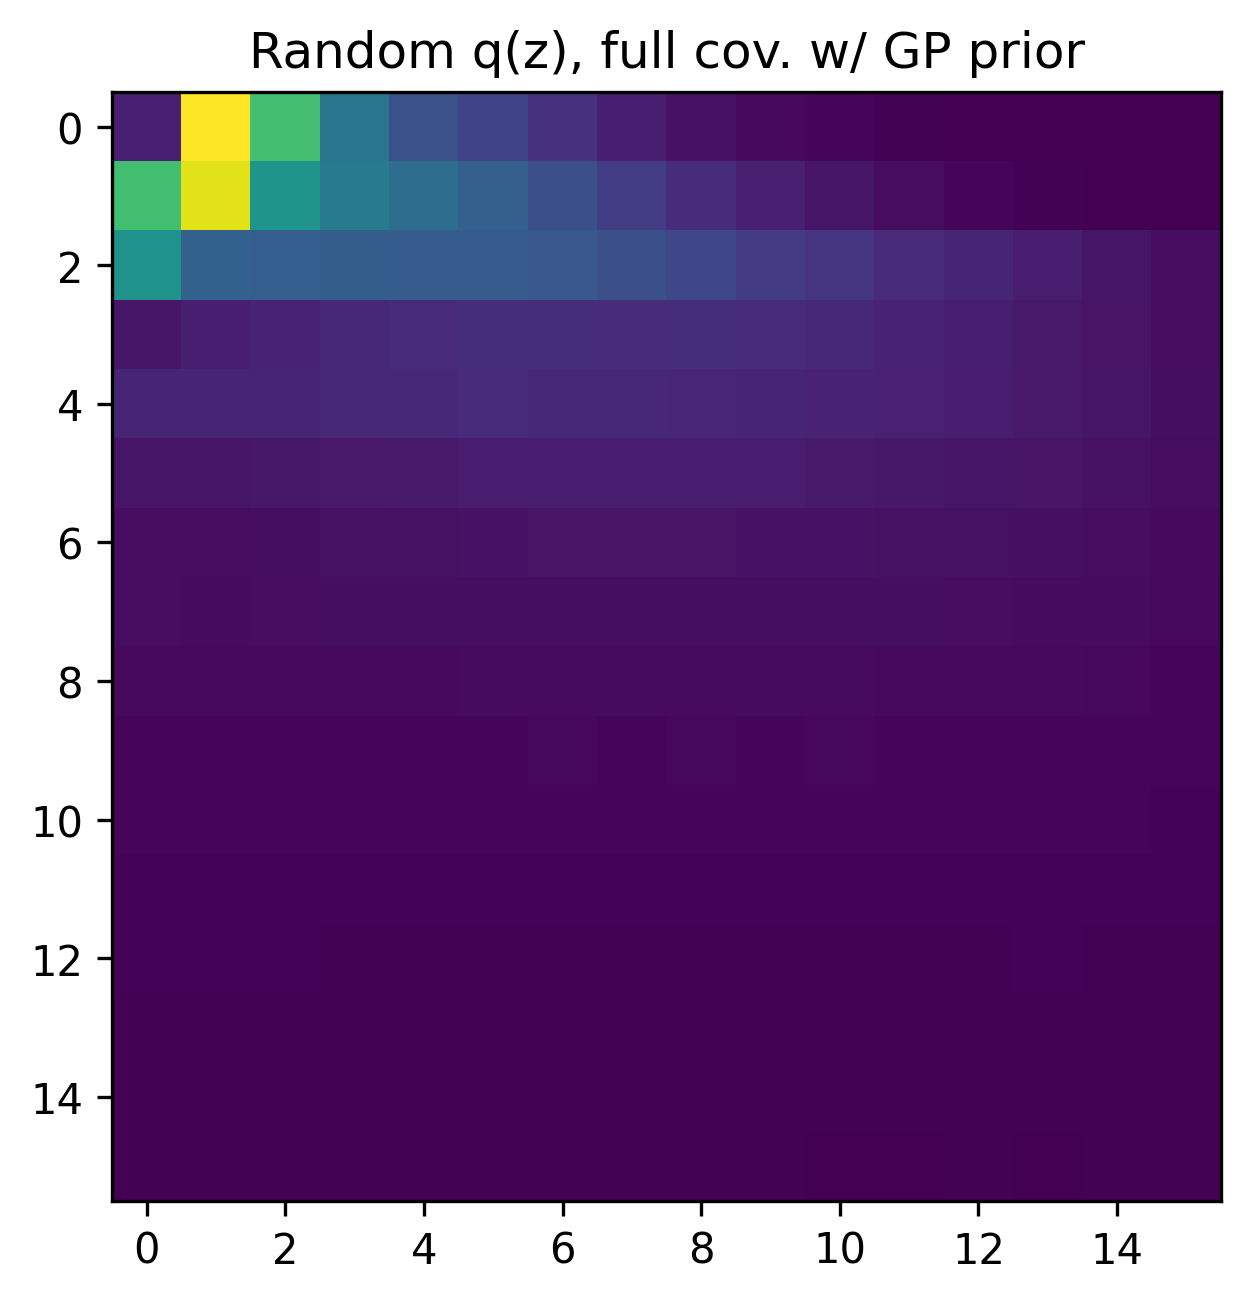

In [86]:
eps = 1e-5
cholesky_cov = torch.cholesky(z_cov + eps*torch.eye(K**2))
z_sample = torch.randn(K**2) @ cholesky_cov
z_sample = z_sample.view(K, K).detach().cpu().squeeze().numpy()


plt.figure()
plt.imshow(z_sample)
plt.title("Random q(z), full cov. w/ GP prior")
plt.show()

torch.Size([256])

#### Benchmark (held-out log-likelihood)

In [ ]:
model_1d_configs = configs.set_model_configs(
    drop_rate = 0.2,
    beta = 0.33,
    pz_std = 1,
    c_base = 128,
    layer_mults = [8, 4],
    ydim = 128, 
    xdim = 128,
    latent_dim = 256,
    device = torch.device('cpu')
)

model_1d = bvae.BetaVAE(model_1d_configs)
model_1d.load_state_dict(torch.load('results/bvae_1d_lowres_std_norm.pt'))

model_2d_configs = configs.set_model_configs(
    drop_rate = 0.2,
    beta = 0.33,
    pz_std = 1,
    ydim = 128,
    xdim = 128,
    latent_dim = 256,
    device = torch.device('cpu')
)

model_2d = bvae.BetaVAE2D(model_2d_configs)
model_2d.load_state_dict(torch.load('results/bvae_2d_lowres_std_norm.pt'))

dataset = CyIFDataset(data_path='../data/cycif/zonation_lowres_test/')
dataloader = DataLoader(dataset, batch_size=model_1d_configs.batch_size, shuffle=False)

In [ ]:
imgs, x_preds_1d, _ = model_eval.predict(model_1d, 
                                         dataloader = dataloader,
                                         device = model_1d_configs.device, 
                                         batch_size = 1)

_, x_preds_2d, _ = model_eval.predict(model_2d,
                                      dataloader = dataloader,
                                      device = model_2d_configs.device,
                                      batch_size = 1)

In [ ]:
MSEs_1d = [((x_true - x_pred)**2).mean()
           for (x_true, x_pred) in zip(imgs, x_preds_1d)]
MSEs_2d = [((x_true - x_pred)**2).mean()
           for (x_true, x_pred) in zip(imgs, x_preds_2d)]

plot_df = pd.DataFrame({
    'MSE': MSEs_1d + MSEs_2d,
    'Label': ['VAE (FC)']*len(imgs) + ['VAE (Conv2D)']*len(imgs)
})

sns.boxplot(x='Label', y='MSE', data=plot_df, hue='Label')
plt.title('Held-out avg. per-pixel MSE')
plt.show()

#### Predictions & Assessment

In [ ]:
dataset = CyIFDataset(data_path='../data/cycif/zonation_lowres/')
dataloader = DataLoader(dataset, batch_size=model_configs.batch_size, shuffle=False)

do_2d = True
if do_2d:
    model = bvae.BetaVAE2D(model_configs)
    model.load_state_dict(torch.load('results/bvae_2d_lowres_std_norm.pt'))
else:
    model = bvae.BetaVAE(model_configs)
    model.load_state_dict(torch.load('results/bvae_1d_lowres_std_norm.pt'))

In [ ]:
imgs, x_preds, qz_preds = model_eval.predict(model, 
                                             dataloader = dataloader,
                                             device = model_configs.device, 
                                             batch_size = 1)

In [ ]:
for i in range(len(x_preds)):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, dpi=200)
    ax1.imshow(imgs[i].transpose(1,2,0))
    ax1.set_title('Input image')
    ax1.axis('off')
    
    ax2.imshow(x_preds[i].transpose(1,2,0))
    ax2.set_title('Reconstructed image')
    ax2.axis('off')

    ax3.imshow(qz_preds[i], cmap='coolwarm')
    ax3.set_title('q(z|x)')
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Visualize channel-wise reconstruction: Can we recover lobule layer units??

idx = 10

fig, axes = plt.subplots(2, 3, figsize=(8, 6), dpi=200)
axes[0, 0].imshow(imgs[idx][0])
axes[0, 0].set_title('GS')
axes[0, 0].axis('off')
axes[0, 1].imshow(imgs[idx][1])
axes[0, 1].set_title('CYP')
axes[0, 1].axis('off')
axes[0, 2].imshow(imgs[idx][2])
axes[0, 2].set_title('ASS')
axes[0, 2].axis('off')

axes[1, 0].imshow(x_preds[idx][0])
axes[1, 0].set_title('GS (pred)')
axes[1, 0].axis('off')
axes[1, 1].imshow(x_preds[idx][1])
axes[1, 1].set_title('CYP (pred)')
axes[1, 1].axis('off')
axes[1, 2].imshow(x_preds[idx][2])
axes[1, 2].set_title('ASS (pred)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


Interpolation attempts:<br>

Given $q(z_1 \mid x_1)$ & $q(z_2 \mid x_2)$, infer $x_{interp}$ btw $x_1$ & $x_2$

In [ ]:
from scipy.ndimage import zoom

def bilinear_zoom(pred0, pred1):
    """
    Baseline bilinear interpolation in image space
    """
    assert pred0.ndim == pred1.ndim == 3 and pred0.shape == pred1.shape, \
        "Images 1 & 2 should have the same dim (C, Y, X)"
    img = np.array([pred0, pred1])
    return zoom(img, (1.5, 1, 1, 1), order=1)[1]  # Only support 2X interpolation now


Benchmark interpolation quality:
- Compare each $MSE(x_i, x_i')$, $MSE(x_i, interp(x'_{i-1}, x'_{i+1}))$ & $MSE(x_i, bilinear(x'_{i-1}, x'_{i+1}))$

In [ ]:
x_interps = [model_eval.interp(model, imgs[i-1], imgs[i+1])
             for i in range(1, len(imgs)-1)]

x_bilinear = [bilinear_zoom(x_preds[i-1], x_preds[i+1])
              for i in range(1, len(imgs)-1)]

MSEs_pred = [((imgs[i] - x_preds[i])**2).mean()
             for i in range(1, len(imgs)-1)]

MSEs_interp = [((imgs[i+1] - x_interps[i])**2).mean()
               for i in range(len(x_interps))]

MSEs_bilinear = [((imgs[i+1] - x_bilinear[i])**2).mean()
                 for i in range(len(x_bilinear))]


plot_df = pd.DataFrame({
    'MSE': MSEs_pred + MSEs_bilinear + MSEs_interp,
    'Label': [r'$X_{true}$ vs. $X_{pred}$']*len(MSEs_pred) + \
             [r'$X_{true}$ vs. $X_{bilinear}$']*len(MSEs_bilinear) + \
             [r'$X_{true}$ vs. $X_{interp}$']*len(MSEs_interp)
})

sns.boxplot(x='Label', y='MSE', data=plot_df, hue='Label')
plt.title('Avg. per-pixel MSE')
plt.show()

Interpretability of $z$'s:

In [ ]:
mat_imgs = np.array([img.flatten() for img in imgs])

R1 = np.corrcoef(mat_imgs)
sns.heatmap(R1, vmax=0.5, cmap='coolwarm')
plt.title('Correlation (Xs) across Z-axis')
plt.show()

del R1, mat_imgs

In [ ]:
mat_preds = np.array([pred.flatten() for pred in x_preds])

R1 = np.corrcoef(mat_preds)
sns.heatmap(R1, vmax=0.5, cmap='coolwarm')
plt.title("Correlation (X's) across Z-axis")
plt.show()

del R1, mat_preds

In [ ]:
latents = [model_eval.get_latent(model, img) for img in imgs]

R1 = np.corrcoef(latents)
sns.heatmap(R1, vmax=0.5, cmap='coolwarm')
plt.title('Correlation (latent variables) across Z-axis')
plt.show()

del R1

---